# Experiment 5: Decision Tree and Random Forest

In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# Experiment 5: Decision Tree and Random Forest

Prepared as a self-contained submission notebook for the Wisconsin Diagnostic Breast Cancer classification experiment.
"""))



# Experiment 5: Decision Tree and Random Forest

Prepared as a self-contained submission notebook for the Wisconsin Diagnostic Breast Cancer classification experiment.


## Aim

In [2]:
display(Markdown("""**Aim:** Implement a Decision Tree classifier and extend it into a Random Forest ensemble on the Wisconsin Diagnostic Breast Cancer dataset using the processed data produced by the reusable EDA notebook."""))


**Aim:** Implement a Decision Tree classifier and extend it into a Random Forest ensemble on the Wisconsin Diagnostic Breast Cancer dataset using the processed data produced by the reusable EDA notebook.

## Objective

In [3]:
display(Markdown("""
**Objectives**
- Reuse the EDA notebook for dataset loading, preprocessing, and train-test split.
- Train a baseline Decision Tree classifier and a baseline Random Forest classifier.
- Perform 5-fold cross-validated hyperparameter tuning for both models.
- Study how tree depth and ensemble size affect overfitting and generalization.
- Compare the single-tree and ensemble-tree models using accuracy, precision, recall, F1 score, ROC-AUC, and timing.
- Generate the required plots, tables, observations, conclusion, and a markdown report.
"""))



**Objectives**
- Reuse the EDA notebook for dataset loading, preprocessing, and train-test split.
- Train a baseline Decision Tree classifier and a baseline Random Forest classifier.
- Perform 5-fold cross-validated hyperparameter tuning for both models.
- Study how tree depth and ensemble size affect overfitting and generalization.
- Compare the single-tree and ensemble-tree models using accuracy, precision, recall, F1 score, ROC-AUC, and timing.
- Generate the required plots, tables, observations, conclusion, and a markdown report.


## Brief Theory

In [4]:
display(Markdown("""
**Brief Theory**
- A Decision Tree recursively splits the feature space using an impurity measure (Gini index or entropy) to build a set of interpretable decision rules; an unconstrained tree can grow deep enough to fit noise in the training data, which drives its high variance.
- A Random Forest trains many decision trees on bootstrapped samples of the data, restricts each split to a random subset of features, and combines the trees by majority vote; bagging plus feature randomness decorrelates the trees enough to reduce the variance a single tree carries.
- 5-fold cross-validation with GridSearchCV selects the hyperparameter values that generalize best on held-out folds rather than the values that simply fit the training set best.
"""))



**Brief Theory**
- A Decision Tree recursively splits the feature space using an impurity measure (Gini index or entropy) to build a set of interpretable decision rules; an unconstrained tree can grow deep enough to fit noise in the training data, which drives its high variance.
- A Random Forest trains many decision trees on bootstrapped samples of the data, restricts each split to a random subset of features, and combines the trees by majority vote; bagging plus feature randomness decorrelates the trees enough to reduce the variance a single tree carries.
- 5-fold cross-validation with GridSearchCV selects the hyperparameter values that generalize best on held-out folds rather than the values that simply fit the training set best.


## Import Libraries

In [5]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)


## Configuration

In [6]:
DATASET_NAME = "Wisconsin Diagnostic Breast Cancer"
TARGET_COLUMN = "diagnosis"
RANDOM_STATE = 42
TEST_SIZE = 0.2
EDA_NOTEBOOK_PATH = "../Ass1/EDA_Pipeline.ipynb"
OUTPUT_DIRECTORY = "experiment5_output"
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
EDA_OUTPUT_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "eda_reuse")
LOCAL_BREAST_CANCER_CSV = "breast_cancer.csv"
UCI_REFERENCE = "https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic"

os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)


def resolve_breast_cancer_csv():
    candidate = Path(LOCAL_BREAST_CANCER_CSV)
    if candidate.exists():
        return str(candidate)
    data = load_breast_cancer(as_frame=True)
    frame = data.frame.copy()
    frame[TARGET_COLUMN] = frame["target"].map(dict(enumerate(["M", "B"])))
    frame = frame.drop(columns=["target"])
    frame.to_csv(candidate, index=False)
    return str(candidate)


CSV_PATH = resolve_breast_cancer_csv()
OUTPUT_DIRECTORY = EDA_OUTPUT_DIRECTORY
print(f"Dataset path resolved to: {CSV_PATH}")
print(f"EDA notebook path: {EDA_NOTEBOOK_PATH}")
print(f"Experiment output directory: {Path(PLOTS_DIRECTORY).resolve()}")
print(f"UCI reference: {UCI_REFERENCE}")


Dataset path resolved to: breast_cancer.csv
EDA notebook path: ../Ass1/EDA_Pipeline.ipynb
Experiment output directory: /Users/vijayaraaghavanks/Dev/college/SEM-5/ML/Ass5/experiment5_output/plots
UCI reference: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


## Run EDA Notebook

Dataset: Wisconsin Diagnostic Breast Cancer
Shape: (569, 31)
Rows: 569
Columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,M
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,M
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,M
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,M
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,M


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
204,12.47,18.60,81.09,481.9,0.0997,0.1058,0.0800,0.0382,0.1925,0.0637,...,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,B
70,18.94,21.31,123.60,1130.0,0.0901,0.1029,0.1080,0.0795,0.1582,0.0546,...,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.1789,0.2551,0.0659,M
131,15.46,19.48,101.70,748.9,0.1092,0.1223,0.1466,0.0809,0.1931,0.0580,...,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.1514,0.2837,0.0802,M
431,12.40,17.68,81.47,467.8,0.1054,0.1316,0.0774,0.0280,0.1811,0.0710,...,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.0737,0.2556,0.0936,B
540,11.54,14.44,74.65,402.9,0.0998,0.1120,0.0674,0.0259,0.1818,0.0678,...,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.0692,0.2329,0.0813,B


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,16.2692,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,4.8332,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,7.9300,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,13.0100,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,14.9700,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,18.7900,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,...,36.0400,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,357
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839,NaN
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181,NaN
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550,NaN
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715,NaN
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800,NaN
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921,NaN


Numerical features: 30
Categorical features: 0
Target type: Categorical
ML task: classification
Duplicate rows: 0
Constant columns: None


,dtype,missing_count,missing_%,unique_values,constant
mean radius,float64,0,0.0,456,False
mean texture,float64,0,0.0,479,False
mean perimeter,float64,0,0.0,522,False
mean area,float64,0,0.0,539,False
mean smoothness,float64,0,0.0,474,False
mean compactness,float64,0,0.0,537,False
mean concavity,float64,0,0.0,537,False
mean concave points,float64,0,0.0,542,False
mean symmetry,float64,0,0.0,432,False
mean fractal dimension,float64,0,0.0,499,False


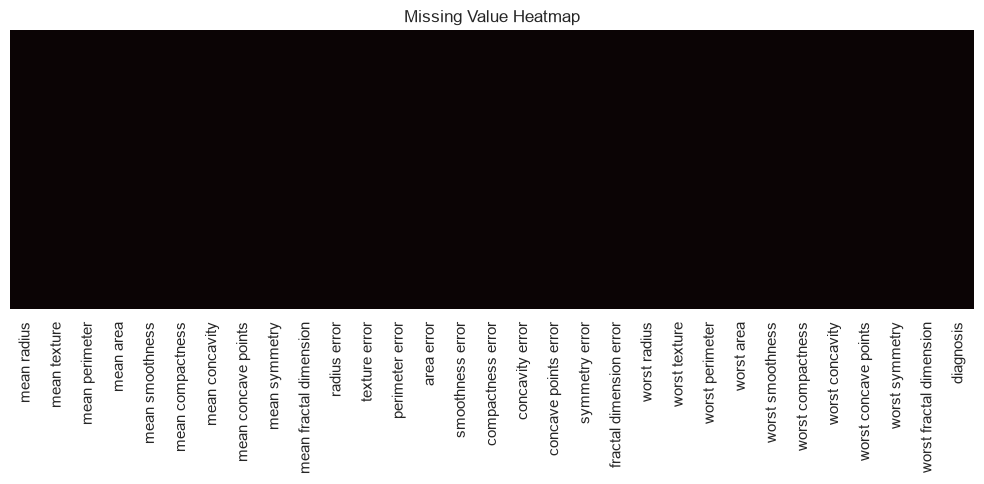

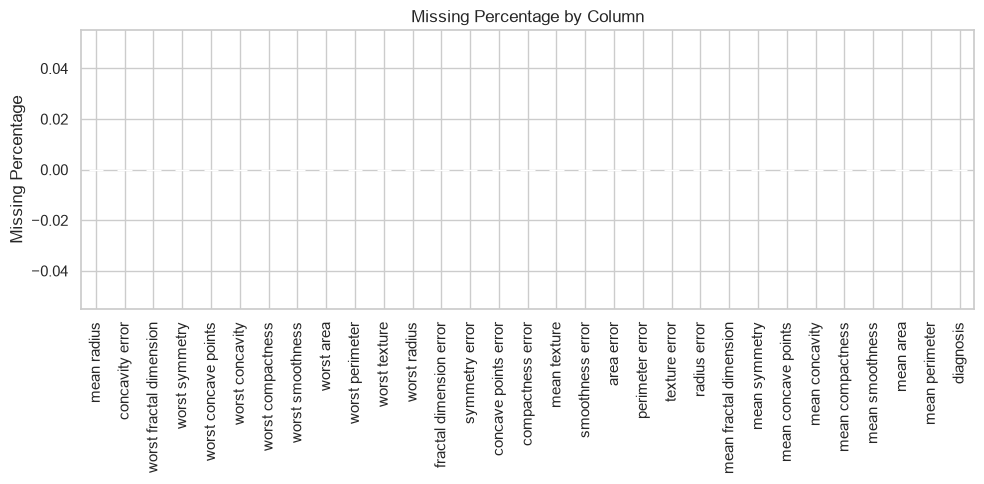

,column,missing_%
0,mean radius,0.0
1,concavity error,0.0
2,worst fractal dimension,0.0
3,worst symmetry,0.0
4,worst concave points,0.0
5,worst concavity,0.0
6,worst compactness,0.0
7,worst smoothness,0.0
8,worst area,0.0
9,worst perimeter,0.0


,feature,iqr_lower,iqr_upper,iqr_outliers,z_score_outliers
0,mean radius,5.5800,21.9000,14,5
1,mean texture,7.7250,30.2450,7,4
2,mean perimeter,31.7750,147.4950,13,7
3,mean area,-123.3000,1326.3000,25,8
4,mean smoothness,0.0580,0.1337,6,5
5,mean compactness,-0.0333,0.2286,16,9
6,mean concavity,-0.1222,0.2824,18,9
7,mean concave points,-0.0602,0.1545,10,6
8,mean symmetry,0.1112,0.2464,15,5
9,mean fractal dimension,0.0451,0.0787,15,7


mean radius: IQR=14, Z-score=5
mean texture: IQR=7, Z-score=4
mean perimeter: IQR=13, Z-score=7
mean area: IQR=25, Z-score=8
mean smoothness: IQR=6, Z-score=5
mean compactness: IQR=16, Z-score=9
mean concavity: IQR=18, Z-score=9
mean concave points: IQR=10, Z-score=6
mean symmetry: IQR=15, Z-score=5
mean fractal dimension: IQR=15, Z-score=7
radius error: IQR=38, Z-score=7
texture error: IQR=20, Z-score=9
perimeter error: IQR=38, Z-score=8
area error: IQR=65, Z-score=6
smoothness error: IQR=30, Z-score=7
compactness error: IQR=28, Z-score=12
concavity error: IQR=22, Z-score=6
concave points error: IQR=19, Z-score=6
symmetry error: IQR=27, Z-score=11
fractal dimension error: IQR=28, Z-score=10
worst radius: IQR=17, Z-score=6
worst texture: IQR=5, Z-score=4
worst perimeter: IQR=15, Z-score=6
worst area: IQR=35, Z-score=10
worst smoothness: IQR=7, Z-score=3
worst compactness: IQR=16, Z-score=10
worst concavity: IQR=12, Z-score=7
worst concave points: IQR=0, Z-score=0
worst symmetry: IQR=23

,feature,test,statistic,p_value,normal
0,mean radius,Shapiro,0.9411,3.1056e-14,False
1,mean texture,Shapiro,0.9767,7.2836e-08,False
2,mean perimeter,Shapiro,0.9362,7.0114e-15,False
3,mean area,Shapiro,0.8584,3.1963e-22,False
4,mean smoothness,Shapiro,0.9875,8.6008e-05,False
5,mean compactness,Shapiro,0.9170,3.9672e-17,False
6,mean concavity,Shapiro,0.8668,1.3386e-21,False
7,mean concave points,Shapiro,0.8917,1.4046e-19,False
8,mean symmetry,Shapiro,0.9726,7.8848e-09,False
9,mean fractal dimension,Shapiro,0.9233,1.9566e-16,False


,feature,test,statistic,p_value
0,mean radius,ANOVA,646.9810,8.4659e-96
1,mean texture,ANOVA,118.0961,4.0586e-25
2,mean perimeter,ANOVA,697.2353,8.4363e-101
3,mean area,ANOVA,573.0607,4.7346e-88
4,mean smoothness,ANOVA,83.6511,1.0519e-18
5,mean compactness,ANOVA,313.2331,3.9383e-56
6,mean concavity,ANOVA,533.7931,9.9666e-84
7,mean concave points,ANOVA,861.6760,7.1012e-116
8,mean symmetry,ANOVA,69.5274,5.7334e-16
9,mean fractal dimension,ANOVA,0.0935,7.5994e-01


**Pearson Correlation Matrix**

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.0000,0.3238,0.9979,0.9874,0.1706,0.5061,0.6768,0.8225,0.1477,-0.3116,...,0.9695,0.2970,0.9651,0.9411,0.1196,0.4135,0.5269,0.7442,0.1640,0.0071
mean texture,0.3238,1.0000,0.3295,0.3211,-0.0234,0.2367,0.3024,0.2935,0.0714,-0.0764,...,0.3526,0.9120,0.3580,0.3435,0.0775,0.2778,0.3010,0.2953,0.1050,0.1192
mean perimeter,0.9979,0.3295,1.0000,0.9865,0.2073,0.5569,0.7161,0.8510,0.1830,-0.2615,...,0.9695,0.3030,0.9704,0.9415,0.1505,0.4558,0.5639,0.7712,0.1891,0.0510
mean area,0.9874,0.3211,0.9865,1.0000,0.1770,0.4985,0.6860,0.8233,0.1513,-0.2831,...,0.9627,0.2875,0.9591,0.9592,0.1235,0.3904,0.5126,0.7220,0.1436,0.0037
mean smoothness,0.1706,-0.0234,0.2073,0.1770,1.0000,0.6591,0.5220,0.5537,0.5578,0.5848,...,0.2131,0.0361,0.2389,0.2067,0.8053,0.4725,0.4349,0.5031,0.3943,0.4993
mean compactness,0.5061,0.2367,0.5569,0.4985,0.6591,1.0000,0.8831,0.8311,0.6026,0.5654,...,0.5353,0.2481,0.5902,0.5096,0.5655,0.8658,0.8163,0.8156,0.5102,0.6874
mean concavity,0.6768,0.3024,0.7161,0.6860,0.5220,0.8831,1.0000,0.9214,0.5007,0.3368,...,0.6882,0.2999,0.7296,0.6760,0.4488,0.7550,0.8841,0.8613,0.4095,0.5149
mean concave points,0.8225,0.2935,0.8510,0.8233,0.5537,0.8311,0.9214,1.0000,0.4625,0.1669,...,0.8303,0.2928,0.8559,0.8096,0.4528,0.6675,0.7524,0.9102,0.3757,0.3687
mean symmetry,0.1477,0.0714,0.1830,0.1513,0.5578,0.6026,0.5007,0.4625,1.0000,0.4799,...,0.1857,0.0907,0.2192,0.1772,0.4267,0.4732,0.4337,0.4303,0.6998,0.4384
mean fractal dimension,-0.3116,-0.0764,-0.2615,-0.2831,0.5848,0.5654,0.3368,0.1669,0.4799,1.0000,...,-0.2537,-0.0513,-0.2052,-0.2319,0.5049,0.4588,0.3462,0.1753,0.3340,0.7673


**Spearman Correlation Matrix**

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.0000,0.3410,0.9978,0.9996,0.1485,0.4976,0.6457,0.7597,0.1202,-0.3499,...,0.9786,0.3149,0.9716,0.9789,0.1258,0.4914,0.5960,0.7273,0.1747,0.0446
mean texture,0.3410,1.0000,0.3481,0.3441,0.0246,0.2665,0.3426,0.3069,0.1101,-0.0593,...,0.3665,0.9092,0.3753,0.3683,0.1014,0.2909,0.3397,0.3192,0.1207,0.1161
mean perimeter,0.9978,0.3481,1.0000,0.9971,0.1829,0.5439,0.6820,0.7886,0.1500,-0.3049,...,0.9812,0.3231,0.9790,0.9809,0.1566,0.5346,0.6321,0.7575,0.1990,0.0890
mean area,0.9996,0.3441,0.9971,1.0000,0.1381,0.4890,0.6426,0.7552,0.1139,-0.3584,...,0.9793,0.3182,0.9718,0.9803,0.1197,0.4858,0.5937,0.7234,0.1709,0.0388
mean smoothness,0.1485,0.0246,0.1829,0.1381,1.0000,0.6788,0.5185,0.5652,0.5422,0.5885,...,0.2035,0.0606,0.2263,0.1917,0.7961,0.4814,0.4291,0.4989,0.3936,0.5115
mean compactness,0.4976,0.2665,0.5439,0.4890,0.6788,1.0000,0.8965,0.8483,0.5522,0.4992,...,0.5426,0.2553,0.5923,0.5316,0.5789,0.9010,0.8379,0.8255,0.4503,0.6890
mean concavity,0.6457,0.3426,0.6820,0.6426,0.5185,0.8965,1.0000,0.9274,0.4468,0.2582,...,0.6823,0.3359,0.7224,0.6766,0.4888,0.8500,0.9385,0.9049,0.3837,0.5418
mean concave points,0.7597,0.3069,0.7886,0.7552,0.5652,0.8483,0.9274,1.0000,0.4238,0.1427,...,0.7874,0.3006,0.8140,0.7804,0.4900,0.7583,0.8273,0.9371,0.3555,0.4211
mean symmetry,0.1202,0.1101,0.1500,0.1139,0.5422,0.5522,0.4468,0.4238,1.0000,0.4285,...,0.1646,0.1189,0.1905,0.1545,0.4242,0.4408,0.3945,0.3975,0.7104,0.4101
mean fractal dimension,-0.3499,-0.0593,-0.3049,-0.3584,0.5885,0.4992,0.2582,0.1427,0.4285,1.0000,...,-0.2945,-0.0478,-0.2475,-0.3049,0.4935,0.4037,0.2426,0.1392,0.2950,0.7608


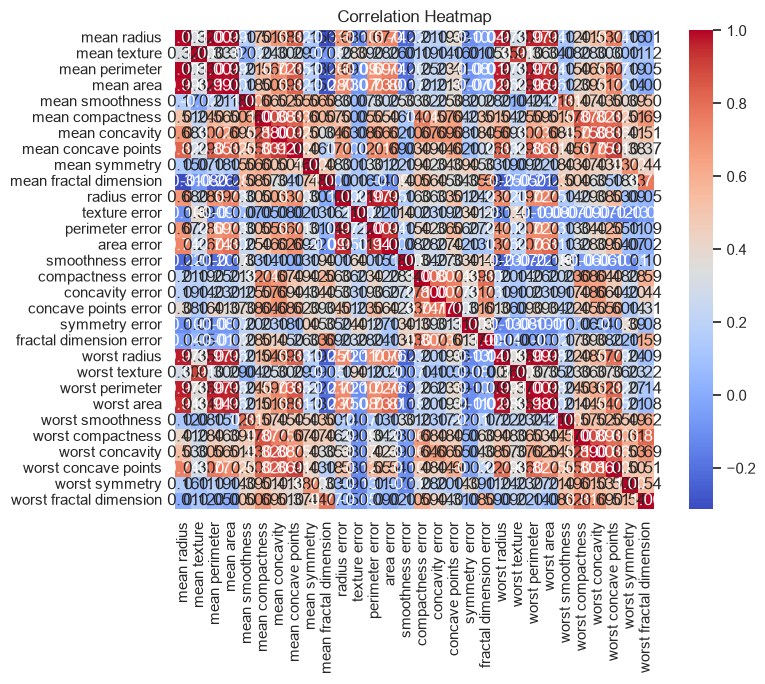

Highly correlated pairs: 44


,feature_1,feature_2,correlation
0,mean radius,mean perimeter,0.9979
1,mean radius,mean area,0.9874
2,mean radius,mean concave points,0.8225
3,mean radius,worst radius,0.9695
4,mean radius,worst perimeter,0.9651
5,mean radius,worst area,0.9411
6,mean texture,worst texture,0.9120
7,mean perimeter,mean area,0.9865
8,mean perimeter,mean concave points,0.8510
9,mean perimeter,worst radius,0.9695


,diagnosis,count
0,B,357
1,M,212


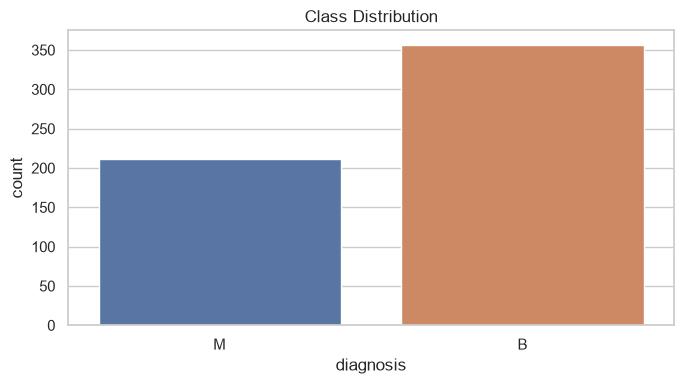

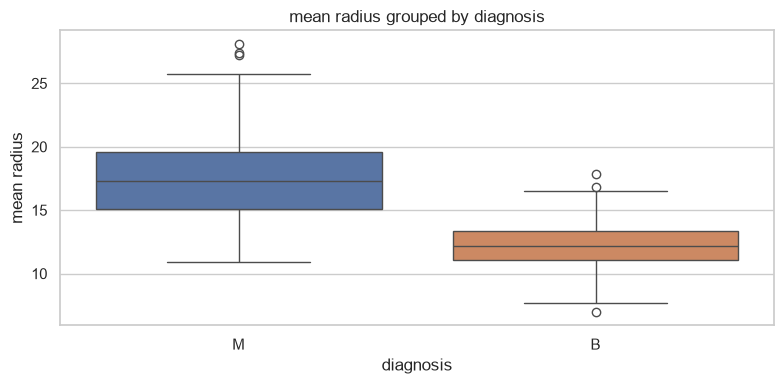

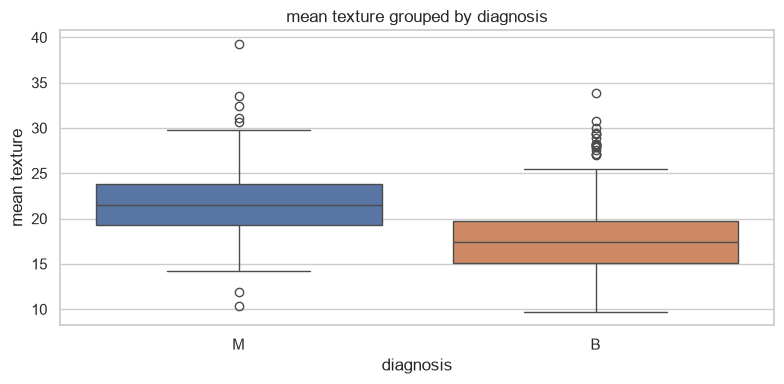

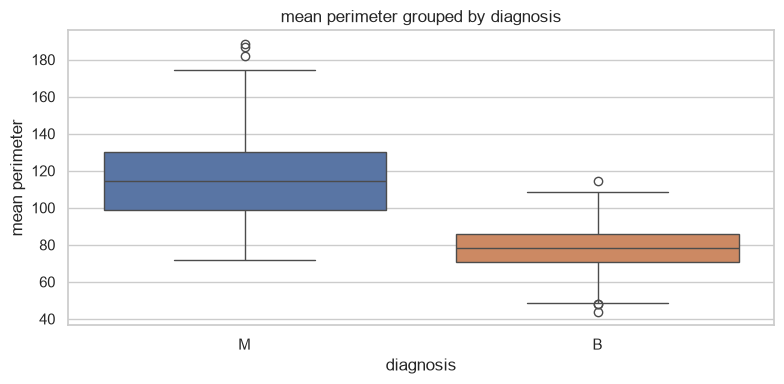

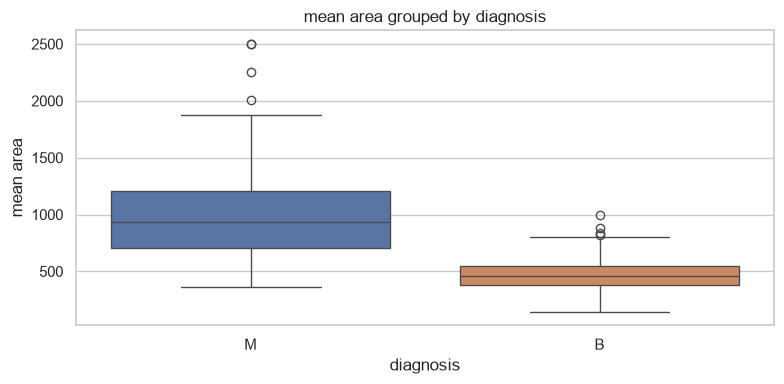

Training shape: (455, 30)
Testing shape: (114, 30)
Encoded features: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
10,0.5186,0.8918,0.4246,0.3839,-0.9747,-0.6898,-0.6886,-0.3982,-1.0392,-0.8251,...,0.5798,1.3132,0.4669,0.4460,-0.5962,-0.6347,-0.6102,-0.2357,0.0546,0.0218
170,-0.5164,-1.6397,-0.5413,-0.5430,0.4762,-0.6318,-0.6043,-0.3031,0.5215,-0.4545,...,-0.5825,-1.6903,-0.6119,-0.5870,0.2736,-0.8148,-0.7127,-0.3232,-0.1376,-0.9044
407,-0.3681,0.4555,-0.3882,-0.4030,-1.4330,-0.3839,-0.3422,-0.7655,-0.8509,-0.2262,...,-0.3986,0.1820,-0.4754,-0.4208,-1.6228,-0.3914,-0.4313,-0.8908,-0.6759,-0.1440
430,0.2053,0.7262,0.4003,0.0706,0.2433,2.2036,2.2561,1.2132,0.8185,0.8998,...,-0.0003,0.2742,0.5138,-0.0995,0.4185,2.8660,2.9586,1.9771,-0.0756,1.7288
27,1.2430,0.1942,1.2104,1.2067,-0.1114,0.0513,0.7330,0.7138,-0.4272,-0.8222,...,1.0128,0.2231,0.9385,0.8809,0.0732,-0.2770,0.3278,0.5019,-0.9093,-0.5462


,feature,select_k_best_score,p_value,mutual_information
20,worst radius,692.8614,2.4837e-93,0.4612
22,worst perimeter,717.2465,2.0930e-95,0.4546
23,worst area,522.1889,1.9324e-77,0.4533
7,mean concave points,684.5268,1.3009e-92,0.4460
27,worst concave points,733.7249,8.7786e-97,0.4329
2,mean perimeter,548.4132,4.6875e-80,0.4093
3,mean area,444.8575,2.6912e-69,0.3747
0,mean radius,511.2748,2.4851e-76,0.3733
6,mean concavity,397.5921,5.7819e-64,0.3541
13,area error,180.5612,6.9984e-35,0.3500


,component,explained_variance_ratio
0,PC1,0.4459
1,PC2,0.1855


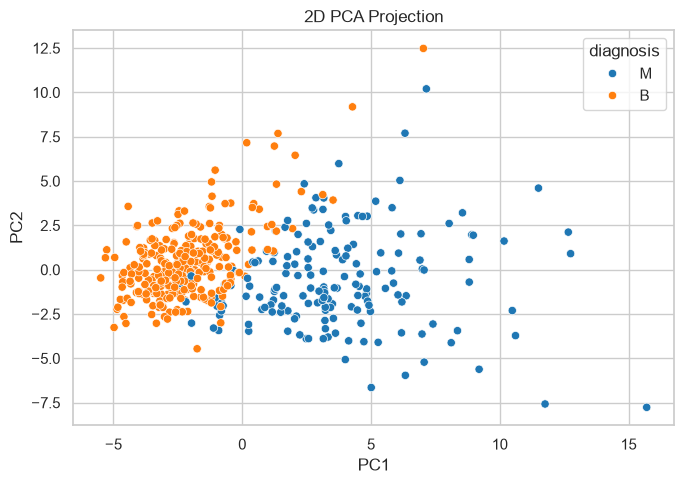

Dataset contains 569 samples and 31 columns.
Detected 30 numerical features and 0 categorical features.
Target column `diagnosis` is treated as Categorical; task type is classification.
Duplicate rows: 0.
Columns with missing values: 0.
Highly correlated feature pairs: 44.
Constant features: None.
Suggested models: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, SVM.
Report saved to: experiment5_output/eda_reuse/eda_report.md
Plots saved to: experiment5_output/eda_reuse/plots


In [7]:
%run $EDA_NOTEBOOK_PATH

## Receive Processed Dataset

In [8]:
assert problem_type == "classification", "Experiment 5 requires a classification dataset."
assert TARGET_COLUMN == "diagnosis", "Experiment 5 expects the target column to be named 'diagnosis'."

required_variables = ["X_train", "X_test", "y_train", "y_test", "feature_names", "preprocessor", "problem_type"]
missing_variables = [name for name in required_variables if name not in globals()]
assert not missing_variables, f"Missing variables from EDA notebook: {missing_variables}"

classes = np.array(sorted(pd.Series(y_train).dropna().unique()))
assert len(classes) == 2, f"This notebook is designed for binary classification, found classes: {classes}"
positive_label = classes[-1]
negative_label = classes[0]

experiment_rows = []
model_store = {}
classification_reports = {}
plot_registry = []


def sanitize_filename(name: str) -> str:
    cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", name).strip("_").lower()
    return cleaned or "plot"


def save_current_plot(filename: str):
    output_path = os.path.join(PLOTS_DIRECTORY, filename)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=160)
    plot_registry.append(output_path)
    plt.show()


def measure_execution_time(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed


def predict_scores(model, features):
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)
        return probabilities[:, 1] if probabilities.ndim == 2 else probabilities
    if hasattr(model, "decision_function"):
        return model.decision_function(features)
    return None


def metric_dict(y_true, y_pred, y_score=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "ROC-AUC": np.nan,
    }
    if y_score is not None:
        encoded_true = (pd.Series(y_true).to_numpy() == positive_label).astype(int)
        metrics["ROC-AUC"] = roc_auc_score(encoded_true, y_score)
    return metrics


def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(5.2, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    save_current_plot(f"confusion_matrix_{sanitize_filename(model_name)}.png")


def plot_roc_curve(model_name, y_true, y_score):
    if y_score is None:
        return
    encoded_true = (pd.Series(y_true).to_numpy() == positive_label).astype(int)
    fpr, tpr, _ = roc_curve(encoded_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4.2))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    save_current_plot(f"roc_curve_{sanitize_filename(model_name)}.png")


def plot_feature_importance(model_name, model, top_n=15):
    if not hasattr(model, "feature_importances_"):
        return None
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).head(top_n)
    plt.figure(figsize=(8, 5.5))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature", legend=False, palette="crest")
    plt.title(f"Feature Importance - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    save_current_plot(f"feature_importance_{sanitize_filename(model_name)}.png")
    return importance_df


def store_results(model_name, metrics, training_time, prediction_time, extra=None):
    payload = {
        "Model": model_name,
        **metrics,
        "Training Time": training_time,
        "Prediction Time": prediction_time,
    }
    if extra:
        payload.update(extra)
    experiment_rows.append(payload)
    return payload


def train_and_evaluate_model(model_name, estimator, plot=True, extra=None):
    model = clone(estimator)
    _, training_time = measure_execution_time(model.fit, X_train, y_train)
    predictions, prediction_time = measure_execution_time(model.predict, X_test)
    scores = predict_scores(model, X_test)
    metrics = metric_dict(y_test, predictions, scores)
    row = store_results(model_name, metrics, training_time, prediction_time, extra=extra)
    model_store[model_name] = model
    report_df = pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).transpose()
    classification_reports[model_name] = report_df

    display(pd.DataFrame([row]))
    display(report_df)
    if plot:
        plot_confusion_matrix(model_name, y_test, predictions)
        plot_roc_curve(model_name, y_test, scores)
    return model, row, report_df


display(Markdown("**Processed dataset received from EDA**"))
summary_table = pd.DataFrame({
    "Artifact": ["X_train", "X_test", "y_train", "y_test", "Feature Count", "Positive Label", "Negative Label"],
    "Value": [X_train.shape, X_test.shape, y_train.shape, y_test.shape, len(feature_names), positive_label, negative_label],
})
display(summary_table)
display(pd.Series(y_train).value_counts().rename_axis(TARGET_COLUMN).reset_index(name="train_count"))


**Processed dataset received from EDA**

,Artifact,Value
0,X_train,"(455, 30)"
1,X_test,"(114, 30)"
2,y_train,"(455,)"
3,y_test,"(114,)"
4,Feature Count,30
5,Positive Label,M
6,Negative Label,B


,diagnosis,train_count
0,B,285
1,M,170


## Decision Tree

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246,0.0034,0.0002


,precision,recall,f1-score,support
B,0.9444,0.9444,0.9444,72.0000
M,0.9048,0.9048,0.9048,42.0000
accuracy,0.9298,0.9298,0.9298,0.9298
macro avg,0.9246,0.9246,0.9246,114.0000
weighted avg,0.9298,0.9298,0.9298,114.0000


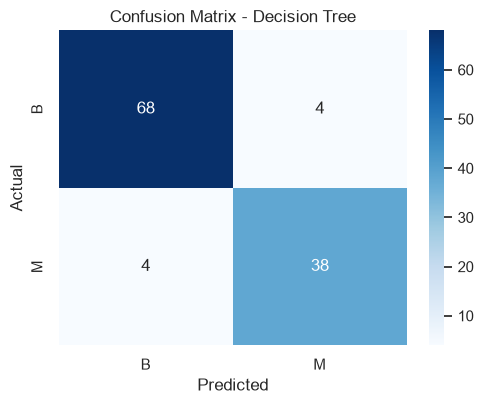

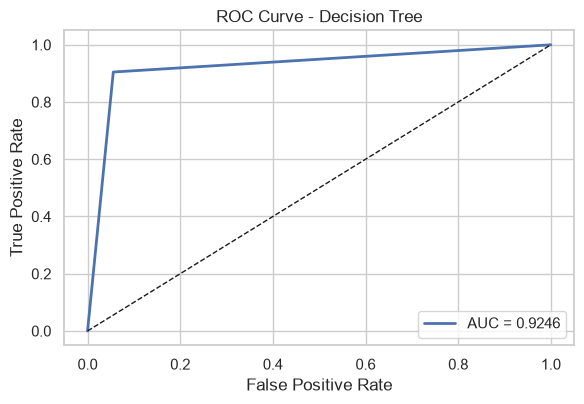

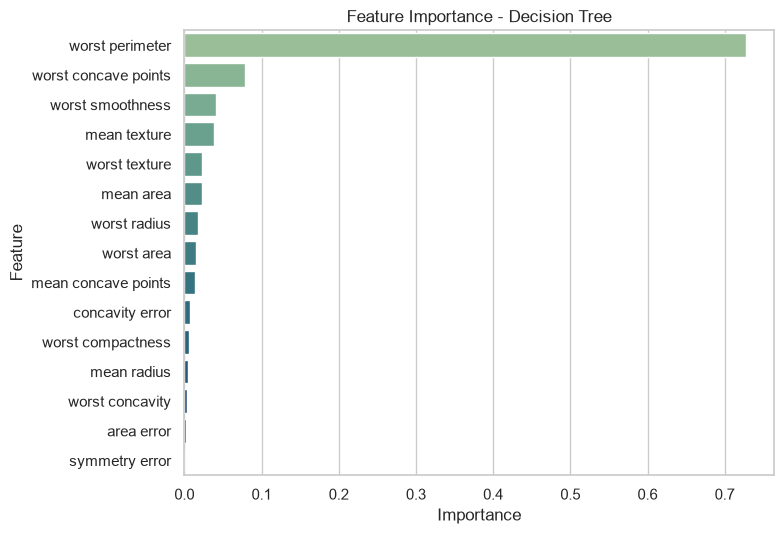

In [9]:
decision_tree_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_model, decision_tree_result, decision_tree_report = train_and_evaluate_model("Decision Tree", decision_tree_baseline)
baseline_dt_importance = plot_feature_importance("Decision Tree", decision_tree_model)


## Decision Tree Hyperparameter Tuning

,Model,Search Method,Best Parameters,Best CV Accuracy,Execution Time
0,Decision Tree,GridSearchCV,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}",0.9363,1.8366


,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,5,93.63,0.9121
1,entropy,7,93.41,0.9094
2,entropy,10,93.41,0.9094
3,entropy,None,93.41,0.9094
4,gini,7,92.97,0.9039
5,gini,10,92.97,0.9039
6,gini,None,92.97,0.9039
7,gini,3,92.75,0.8990
8,entropy,3,92.53,0.8941
9,gini,5,92.53,0.8971


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Decision Tree (Tuned),0.9649,1.0,0.9048,0.95,0.9744,0.0026,0.0003


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


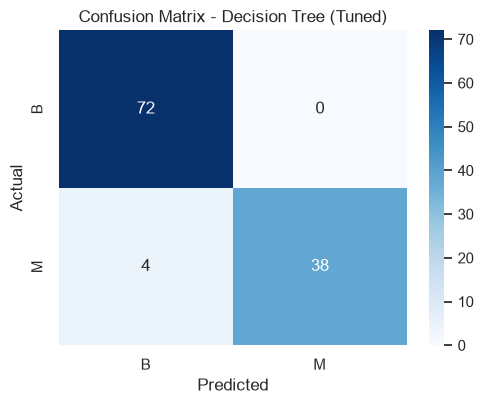

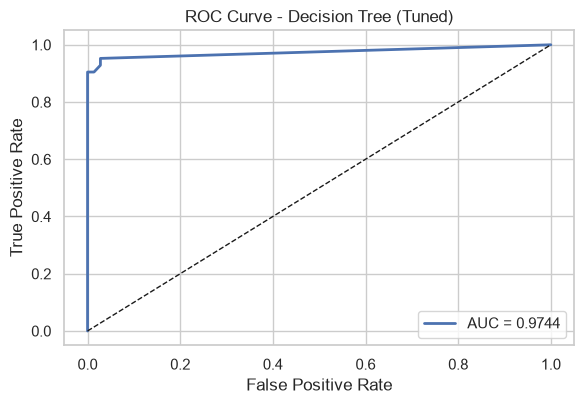

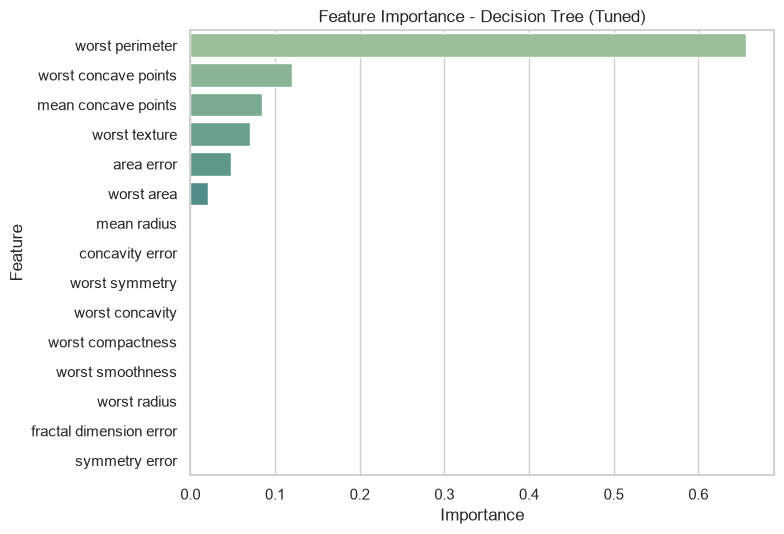

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score, pos_label=positive_label)

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    scoring={"accuracy": "accuracy", "f1": f1_scorer},
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

_, dt_tuning_time = measure_execution_time(dt_grid_search.fit, X_train, y_train)
dt_cv_results = pd.DataFrame(dt_grid_search.cv_results_)
dt_best_params = dt_grid_search.best_params_
dt_best_cv_accuracy = dt_grid_search.best_score_

display(pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(dt_best_params),
        "Best CV Accuracy": dt_best_cv_accuracy,
        "Execution Time": dt_tuning_time,
    }
]))

dt_cv_results["param_max_depth_label"] = dt_cv_results["param_max_depth"].apply(lambda v: "None" if pd.isna(v) else int(v))
dt_grouped = dt_cv_results.sort_values("mean_test_accuracy", ascending=False).groupby(
    ["param_criterion", "param_max_depth_label"], as_index=False
).first()
dt_hyperparameter_table = dt_grouped[["param_criterion", "param_max_depth_label", "mean_test_accuracy", "mean_test_f1"]].copy()
dt_hyperparameter_table.columns = ["Criterion", "Max Depth", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
dt_hyperparameter_table["Avg CV Accuracy (%)"] = (dt_hyperparameter_table["Avg CV Accuracy (%)"] * 100).round(2)
dt_hyperparameter_table["Avg CV F1 Score"] = dt_hyperparameter_table["Avg CV F1 Score"].round(4)
dt_hyperparameter_table = dt_hyperparameter_table.sort_values("Avg CV Accuracy (%)", ascending=False).reset_index(drop=True)
display(dt_hyperparameter_table)

tuned_decision_tree_model, tuned_decision_tree_result, tuned_decision_tree_report = train_and_evaluate_model(
    "Decision Tree (Tuned)",
    dt_grid_search.best_estimator_,
)
tuned_dt_importance = plot_feature_importance("Decision Tree (Tuned)", tuned_decision_tree_model)


## Random Forest

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Random Forest,0.9737,1.0,0.9286,0.963,0.9929,0.0503,0.0024


,precision,recall,f1-score,support
B,0.9600,1.0000,0.9796,72.0000
M,1.0000,0.9286,0.9630,42.0000
accuracy,0.9737,0.9737,0.9737,0.9737
macro avg,0.9800,0.9643,0.9713,114.0000
weighted avg,0.9747,0.9737,0.9735,114.0000


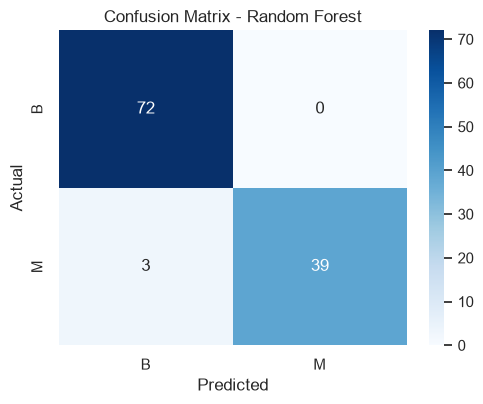

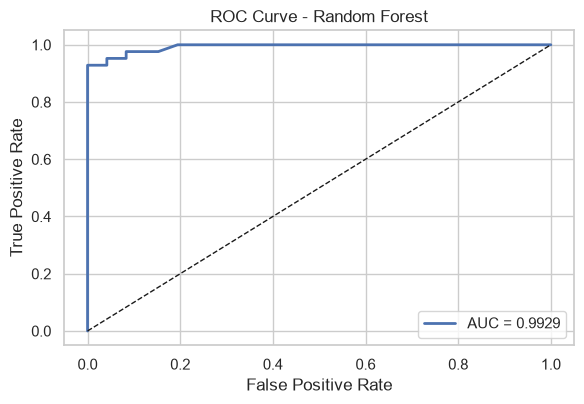

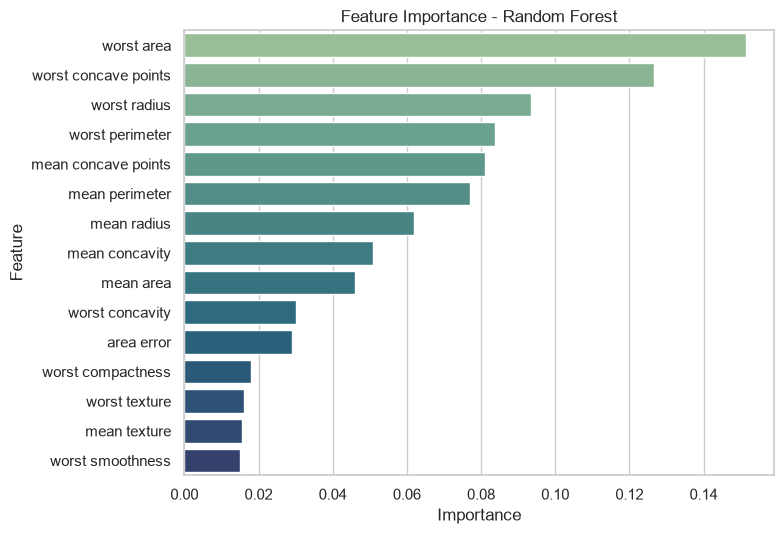

In [11]:
random_forest_baseline = RandomForestClassifier(random_state=RANDOM_STATE)
random_forest_model, random_forest_result, random_forest_report = train_and_evaluate_model("Random Forest", random_forest_baseline)
baseline_rf_importance = plot_feature_importance("Random Forest", random_forest_model)


## Random Forest Hyperparameter Tuning

,Model,Search Method,Best Parameters,Best CV Accuracy,Execution Time
0,Random Forest,GridSearchCV,"{'bootstrap': False, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}",0.9714,1.2757


,n_estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,200,None,sqrt,97.14,0.9615
1,200,5,sqrt,97.14,0.9608
2,50,10,sqrt,97.14,0.9617
3,200,10,sqrt,97.14,0.9615
4,50,10,log2,96.92,0.9584
5,50,None,log2,96.92,0.9584
6,50,None,sqrt,96.92,0.9589
7,100,5,sqrt,96.92,0.9580
8,100,10,log2,96.92,0.9585
9,100,5,log2,96.70,0.9550


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Random Forest (Tuned),0.9649,1.0,0.9048,0.95,0.9937,0.1045,0.0041


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


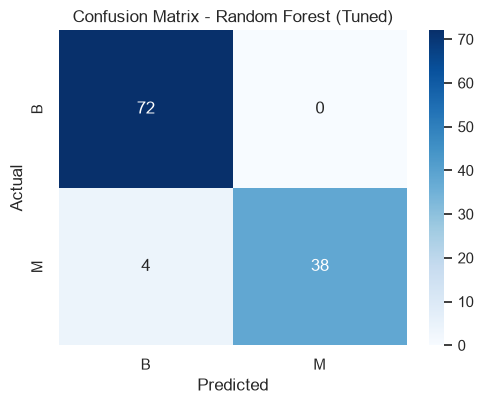

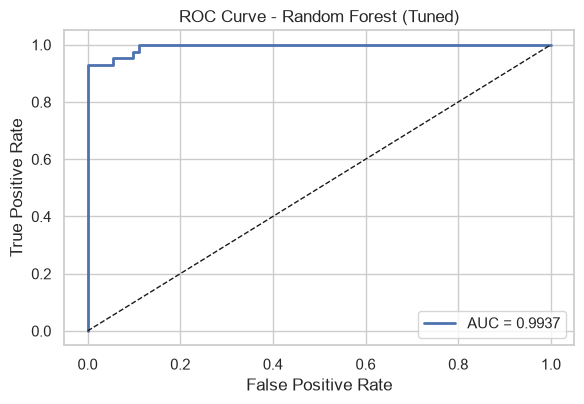

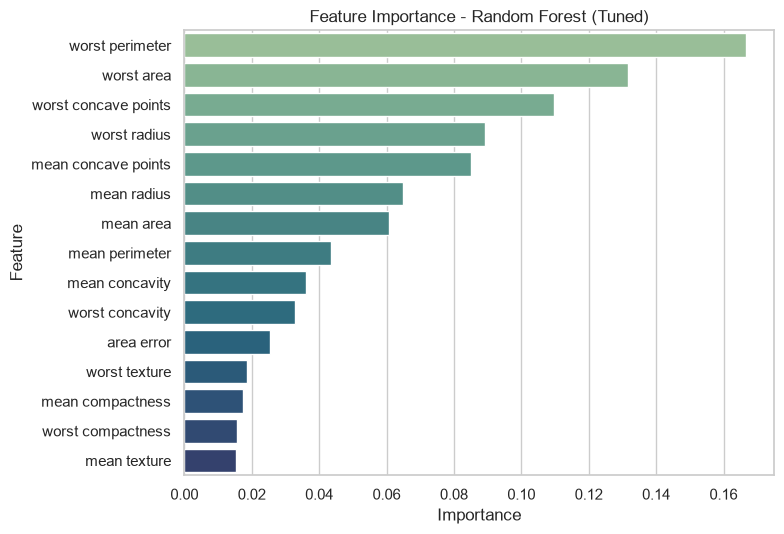

In [12]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    scoring={"accuracy": "accuracy", "f1": f1_scorer},
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

_, rf_tuning_time = measure_execution_time(rf_grid_search.fit, X_train, y_train)
rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)
rf_best_params = rf_grid_search.best_params_
rf_best_cv_accuracy = rf_grid_search.best_score_

display(pd.DataFrame([
    {
        "Model": "Random Forest",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(rf_best_params),
        "Best CV Accuracy": rf_best_cv_accuracy,
        "Execution Time": rf_tuning_time,
    }
]))

rf_cv_results["param_max_depth_label"] = rf_cv_results["param_max_depth"].apply(lambda v: "None" if pd.isna(v) else int(v))
rf_grouped = rf_cv_results.sort_values("mean_test_accuracy", ascending=False).groupby(
    ["param_n_estimators", "param_max_depth_label", "param_max_features"], as_index=False
).first()
rf_hyperparameter_table = rf_grouped[["param_n_estimators", "param_max_depth_label", "param_max_features", "mean_test_accuracy", "mean_test_f1"]].copy()
rf_hyperparameter_table.columns = ["n_estimators", "Max Depth", "Max Features", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
rf_hyperparameter_table["Avg CV Accuracy (%)"] = (rf_hyperparameter_table["Avg CV Accuracy (%)"] * 100).round(2)
rf_hyperparameter_table["Avg CV F1 Score"] = rf_hyperparameter_table["Avg CV F1 Score"].round(4)
rf_hyperparameter_table = rf_hyperparameter_table.sort_values("Avg CV Accuracy (%)", ascending=False).reset_index(drop=True)
display(rf_hyperparameter_table)

tuned_random_forest_model, tuned_random_forest_result, tuned_random_forest_report = train_and_evaluate_model(
    "Random Forest (Tuned)",
    rf_grid_search.best_estimator_,
)
tuned_rf_importance = plot_feature_importance("Random Forest (Tuned)", tuned_random_forest_model)


## Cross Validation

In [13]:
dt_cv_scores = cross_val_score(clone(dt_grid_search.best_estimator_), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
rf_cv_scores = cross_val_score(clone(rf_grid_search.best_estimator_), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

cv_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_cv_scores[0], rf_cv_scores[0]],
    "Fold 2": [dt_cv_scores[1], rf_cv_scores[1]],
    "Fold 3": [dt_cv_scores[2], rf_cv_scores[2]],
    "Fold 4": [dt_cv_scores[3], rf_cv_scores[3]],
    "Fold 5": [dt_cv_scores[4], rf_cv_scores[4]],
    "Average": [dt_cv_scores.mean(), rf_cv_scores.mean()],
})
display(cv_table)


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.9011,0.956,0.9121,0.956,0.956,0.9363
1,Random Forest,0.9560,1.000,0.9451,0.967,0.989,0.9714


## Performance Comparison

In [14]:
results_df = pd.DataFrame(experiment_rows)

decision_tree_performance_table = results_df[results_df["Model"].isin(["Decision Tree", "Decision Tree (Tuned)"])][["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Training Time", "Prediction Time"]].reset_index(drop=True)
random_forest_performance_table = results_df[results_df["Model"].isin(["Random Forest", "Random Forest (Tuned)"])][["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Training Time", "Prediction Time"]].reset_index(drop=True)

hyperparameter_tuning_summary = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(dt_best_params),
        "Best CV Accuracy": dt_best_cv_accuracy,
        "Execution Time": dt_tuning_time,
    },
    {
        "Model": "Random Forest",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(rf_best_params),
        "Best CV Accuracy": rf_best_cv_accuracy,
        "Execution Time": rf_tuning_time,
    },
])

dt_vs_rf_comparison = results_df[results_df["Model"].isin(["Decision Tree (Tuned)", "Random Forest (Tuned)"])][["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Training Time", "Prediction Time"]].reset_index(drop=True)

display(Markdown("### Decision Tree Performance"))
display(decision_tree_performance_table)

display(Markdown("### Random Forest Performance"))
display(random_forest_performance_table)

display(Markdown("### Hyperparameter Tuning Summary"))
display(hyperparameter_tuning_summary)

display(Markdown("### Cross Validation Results"))
display(cv_table)

display(Markdown("### Decision Tree vs Random Forest Comparison"))
display(dt_vs_rf_comparison)


### Decision Tree Performance

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246,0.0034,0.0002
1,Decision Tree (Tuned),0.9649,1.0000,0.9048,0.9500,0.9744,0.0026,0.0003


### Random Forest Performance

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Random Forest,0.9737,1.0,0.9286,0.963,0.9929,0.0503,0.0024
1,Random Forest (Tuned),0.9649,1.0,0.9048,0.950,0.9937,0.1045,0.0041


### Hyperparameter Tuning Summary

,Model,Search Method,Best Parameters,Best CV Accuracy,Execution Time
0,Decision Tree,GridSearchCV,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}",0.9363,1.8366
1,Random Forest,GridSearchCV,"{'bootstrap': False, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}",0.9714,1.2757


### Cross Validation Results

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.9011,0.956,0.9121,0.956,0.956,0.9363
1,Random Forest,0.9560,1.000,0.9451,0.967,0.989,0.9714


### Decision Tree vs Random Forest Comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Decision Tree (Tuned),0.9649,1.0,0.9048,0.95,0.9744,0.0026,0.0003
1,Random Forest (Tuned),0.9649,1.0,0.9048,0.95,0.9937,0.1045,0.0041


## Visualizations

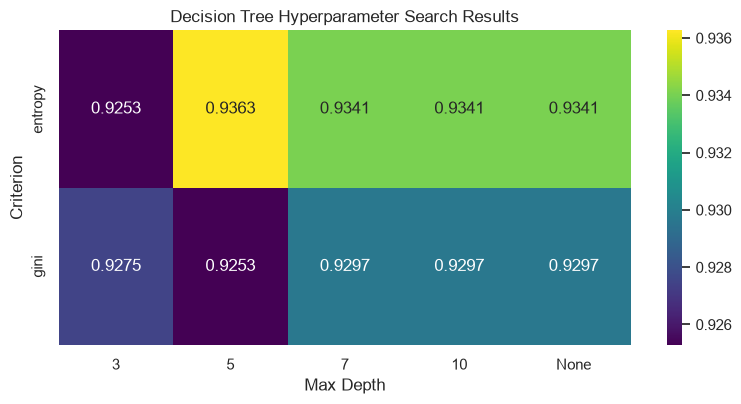

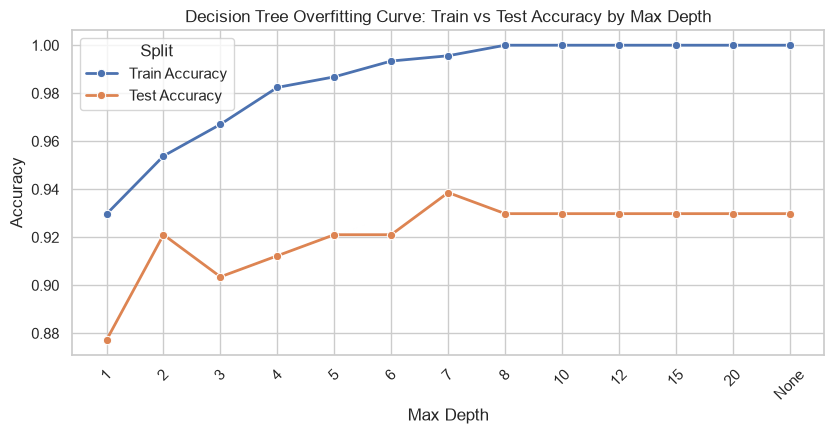

,Max Depth,Train Accuracy,Test Accuracy
0,1,0.9297,0.8772
1,2,0.9538,0.9211
2,3,0.9670,0.9035
3,4,0.9824,0.9123
4,5,0.9868,0.9211
5,6,0.9934,0.9211
6,7,0.9956,0.9386
7,8,1.0000,0.9298
8,10,1.0000,0.9298
9,12,1.0000,0.9298


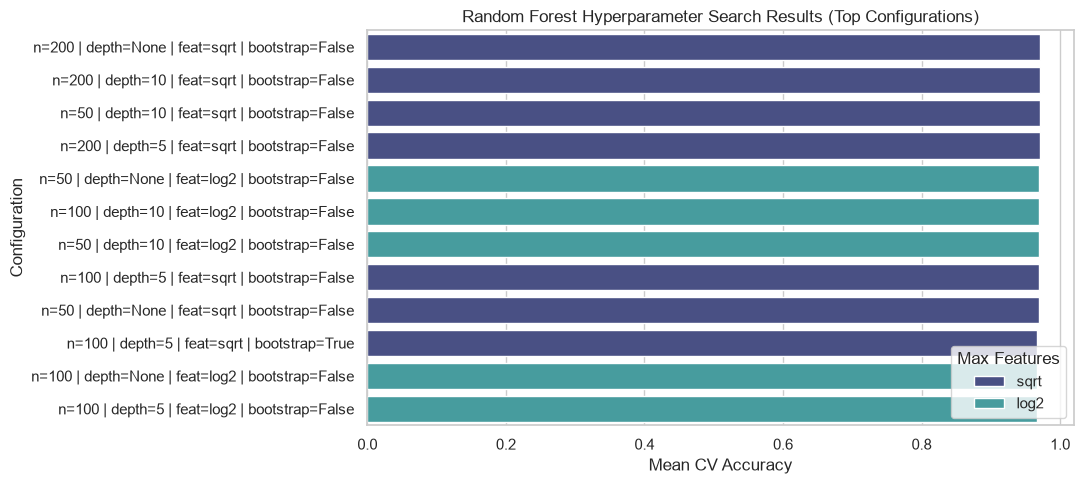

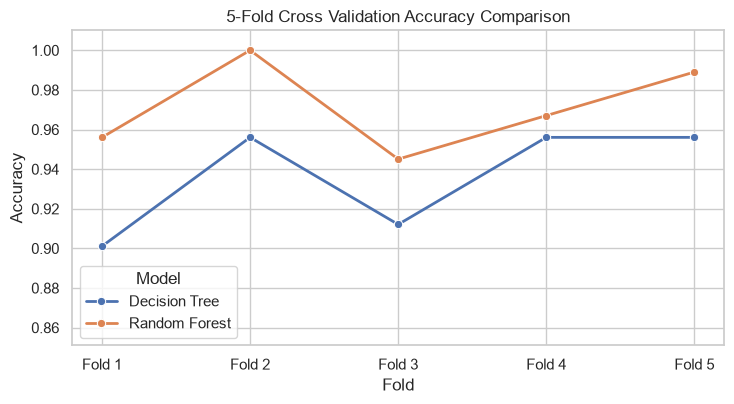

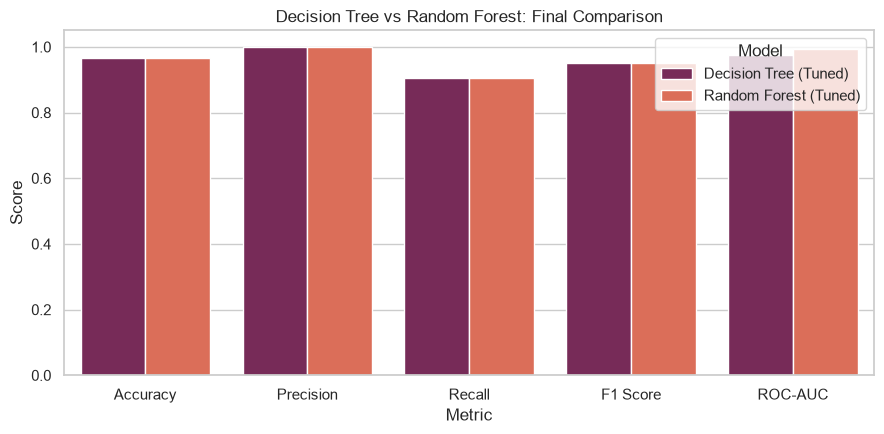

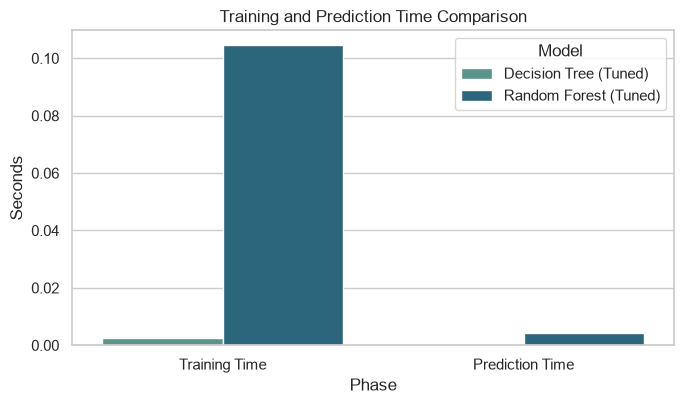

In [15]:
dt_depth_criterion_heatmap = dt_cv_results.groupby(["param_criterion", "param_max_depth_label"])["mean_test_accuracy"].max().unstack()
plt.figure(figsize=(8, 4.2))
sns.heatmap(dt_depth_criterion_heatmap, annot=True, fmt=".4f", cmap="viridis")
plt.title("Decision Tree Hyperparameter Search Results")
plt.xlabel("Max Depth")
plt.ylabel("Criterion")
save_current_plot("decision_tree_hyperparameter_search_results.png")

depth_sweep_values = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
depth_sweep_rows = []
for depth in depth_sweep_values:
    sweep_model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    sweep_model.fit(X_train, y_train)
    depth_sweep_rows.append({
        "Max Depth": depth if depth is not None else "None",
        "Train Accuracy": accuracy_score(y_train, sweep_model.predict(X_train)),
        "Test Accuracy": accuracy_score(y_test, sweep_model.predict(X_test)),
    })
depth_sweep_table = pd.DataFrame(depth_sweep_rows)

depth_labels = [str(d) if d is not None else "None" for d in depth_sweep_values]
depth_sweep_plot_df = depth_sweep_table.melt(id_vars="Max Depth", value_vars=["Train Accuracy", "Test Accuracy"], var_name="Split", value_name="Accuracy")
depth_sweep_plot_df["Max Depth"] = pd.Categorical(depth_sweep_plot_df["Max Depth"].astype(str), categories=depth_labels, ordered=True)
plt.figure(figsize=(8.5, 4.5))
sns.lineplot(data=depth_sweep_plot_df, x="Max Depth", y="Accuracy", hue="Split", marker="o", linewidth=2)
plt.title("Decision Tree Overfitting Curve: Train vs Test Accuracy by Max Depth")
plt.xticks(rotation=45)
save_current_plot("decision_tree_overfitting_curve.png")
display(depth_sweep_table)

rf_top = rf_cv_results.sort_values("mean_test_accuracy", ascending=False).head(12).copy()
rf_top["Configuration"] = rf_top.apply(
    lambda row: f"n={row['param_n_estimators']} | depth={row['param_max_depth_label']} | feat={row['param_max_features']} | bootstrap={row['param_bootstrap']}",
    axis=1,
)
plt.figure(figsize=(11, 5))
sns.barplot(data=rf_top, x="mean_test_accuracy", y="Configuration", hue="param_max_features", dodge=False, palette="mako")
plt.title("Random Forest Hyperparameter Search Results (Top Configurations)")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Configuration")
plt.legend(title="Max Features", loc="lower right")
save_current_plot("random_forest_hyperparameter_search_results.png")

cv_plot_df = cv_table.melt(id_vars="Model", value_vars=["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"], var_name="Fold", value_name="Accuracy")
plt.figure(figsize=(7.5, 4.2))
sns.lineplot(data=cv_plot_df, x="Fold", y="Accuracy", hue="Model", marker="o", linewidth=2)
plt.title("5-Fold Cross Validation Accuracy Comparison")
plt.ylim(max(0.7, cv_plot_df["Accuracy"].min() - 0.05), 1.01)
save_current_plot("cross_validation_accuracy_comparison.png")

comparison_plot_df = dt_vs_rf_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison_plot_df, x="Metric", y="Score", hue="Model", palette="rocket")
plt.title("Decision Tree vs Random Forest: Final Comparison")
plt.ylim(0, 1.05)
save_current_plot("decision_tree_vs_random_forest_comparison.png")

time_plot_df = dt_vs_rf_comparison.melt(
    id_vars="Model",
    value_vars=["Training Time", "Prediction Time"],
    var_name="Phase",
    value_name="Seconds",
)
plt.figure(figsize=(7, 4.2))
sns.barplot(data=time_plot_df, x="Phase", y="Seconds", hue="Model", palette="crest")
plt.title("Training and Prediction Time Comparison")
save_current_plot("time_comparison.png")


## Analysis

In [16]:
def param_impact_range(cv_results, param_col, metric_col="mean_test_accuracy"):
    grouped = cv_results.groupby(param_col)[metric_col].max()
    return grouped.max() - grouped.min(), grouped

dt_impact = {
    "criterion": param_impact_range(dt_cv_results, "param_criterion")[0],
    "max_depth": param_impact_range(dt_cv_results, "param_max_depth_label")[0],
    "min_samples_split": param_impact_range(dt_cv_results, "param_min_samples_split")[0],
    "min_samples_leaf": param_impact_range(dt_cv_results, "param_min_samples_leaf")[0],
}
rf_impact = {
    "n_estimators": param_impact_range(rf_cv_results, "param_n_estimators")[0],
    "max_depth": param_impact_range(rf_cv_results, "param_max_depth_label")[0],
    "max_features": param_impact_range(rf_cv_results, "param_max_features")[0],
    "bootstrap": param_impact_range(rf_cv_results, "param_bootstrap")[0],
}
most_impactful_dt_param = max(dt_impact, key=dt_impact.get)
most_impactful_rf_param = max(rf_impact, key=rf_impact.get)

best_classifier_row = dt_vs_rf_comparison.sort_values(["F1 Score", "ROC-AUC", "Accuracy"], ascending=False).iloc[0]
dt_best_row = dt_cv_results.sort_values("mean_test_accuracy", ascending=False).iloc[0]
rf_best_row = rf_cv_results.sort_values("mean_test_accuracy", ascending=False).iloc[0]
dt_gap = dt_best_row["mean_train_accuracy"] - dt_best_row["mean_test_accuracy"]
rf_gap = rf_best_row["mean_train_accuracy"] - rf_best_row["mean_test_accuracy"]

faster_training_model = dt_vs_rf_comparison.sort_values("Training Time").iloc[0]
faster_prediction_model = dt_vs_rf_comparison.sort_values("Prediction Time").iloc[0]

unbounded_row = depth_sweep_table[depth_sweep_table["Max Depth"] == "None"].iloc[0]
shallow_row = depth_sweep_table.iloc[0]

analysis_answers = [
    f"Best classifier: {best_classifier_row['Model']} achieved Accuracy={best_classifier_row['Accuracy']:.4f}, F1={best_classifier_row['F1 Score']:.4f}, and ROC-AUC={best_classifier_row['ROC-AUC']:.4f} on the held-out test set.",
    f"Decision Tree hyperparameter impact: varying {most_impactful_dt_param} produced the widest swing in best CV accuracy ({dt_impact[most_impactful_dt_param]*100:.2f} percentage points), more than the other three tuned parameters.",
    f"Random Forest hyperparameter impact: varying {most_impactful_rf_param} produced the widest swing in best CV accuracy ({rf_impact[most_impactful_rf_param]*100:.2f} percentage points) among the four tuned parameters.",
    f"Bias-variance trade-off: the tuned Decision Tree had a train-test CV accuracy gap of {dt_gap:.4f}, while the tuned Random Forest had a gap of {rf_gap:.4f}, {'showing the ensemble reduced overfitting' if rf_gap < dt_gap else 'showing the ensemble did not reduce the gap in this run'}.",
    f"Depth sweep: at max_depth={shallow_row['Max Depth']} the tree scored Train={shallow_row['Train Accuracy']:.4f}/Test={shallow_row['Test Accuracy']:.4f}, while an unbounded tree (max_depth=None) scored Train={unbounded_row['Train Accuracy']:.4f}/Test={unbounded_row['Test Accuracy']:.4f}, a train-test gap of {(unbounded_row['Train Accuracy']-unbounded_row['Test Accuracy']):.4f}.",
    f"Computational trade-offs: {faster_training_model['Model']} trained fastest ({faster_training_model['Training Time']:.4f}s), while {faster_prediction_model['Model']} predicted fastest ({faster_prediction_model['Prediction Time']:.4f}s).",
]

for answer in analysis_answers:
    print(f"- {answer}")


- Best classifier: Random Forest (Tuned) achieved Accuracy=0.9649, F1=0.9500, and ROC-AUC=0.9937 on the held-out test set.
- Decision Tree hyperparameter impact: varying max_depth produced the widest swing in best CV accuracy (0.88 percentage points), more than the other three tuned parameters.
- Random Forest hyperparameter impact: varying bootstrap produced the widest swing in best CV accuracy (0.44 percentage points) among the four tuned parameters.
- Bias-variance trade-off: the tuned Decision Tree had a train-test CV accuracy gap of 0.0467, while the tuned Random Forest had a gap of 0.0286, showing the ensemble reduced overfitting.
- Depth sweep: at max_depth=1 the tree scored Train=0.9297/Test=0.8772, while an unbounded tree (max_depth=None) scored Train=1.0000/Test=0.9298, a train-test gap of 0.0702.
- Computational trade-offs: Decision Tree (Tuned) trained fastest (0.0026s), while Decision Tree (Tuned) predicted fastest (0.0003s).


## Observation Questions

In [17]:
dt_final_f1 = decision_tree_performance_table.iloc[-1]["F1 Score"]
rf_final_f1 = random_forest_performance_table.iloc[-1]["F1 Score"]
ensemble_helped = rf_final_f1 > dt_final_f1
best_test_depth_row = depth_sweep_table.loc[depth_sweep_table["Test Accuracy"].idxmax()]

observation_answers = [
    (
        "How does tree depth affect overfitting in Decision Trees?",
        f"The depth sweep shows training accuracy climbing to {depth_sweep_table['Train Accuracy'].max():.4f} as depth grows, while test accuracy peaks at {best_test_depth_row['Test Accuracy']:.4f} around max_depth={best_test_depth_row['Max Depth']}. "
        f"Once the tree is left unbounded (max_depth=None) the train-test gap widens to {(unbounded_row['Train Accuracy']-unbounded_row['Test Accuracy']):.4f}, so deeper trees increasingly memorize the training folds instead of generalizing further on this dataset."
    ),
    (
        "Which hyperparameter had the greatest impact on performance?",
        f"For the Decision Tree, {most_impactful_dt_param} moved the best CV accuracy by {dt_impact[most_impactful_dt_param]*100:.2f} percentage points, and for the Random Forest, {most_impactful_rf_param} moved it by {rf_impact[most_impactful_rf_param]*100:.2f} percentage points. "
        f"Both were the largest swings within their respective search spaces, so {most_impactful_dt_param} and {most_impactful_rf_param} mattered more than the other tuned parameters in this run."
    ),
    (
        "How does Random Forest improve generalization?",
        f"The Random Forest's CV train-test gap ({rf_gap:.4f}) was {'narrower' if rf_gap < dt_gap else 'not narrower'} than the Decision Tree's gap ({dt_gap:.4f}), and its 5-fold CV accuracy averaged {rf_cv_scores.mean():.4f} against {dt_cv_scores.mean():.4f} for the tree. "
        f"This is consistent with bagging and random feature selection averaging out the variance carried by individual trees."
    ),
    (
        "Did ensemble learning always improve performance? Why or why not?",
        f"On the held-out test set, {'Random Forest outperformed the Decision Tree' if ensemble_helped else 'the Decision Tree matched or outperformed the Random Forest'} (RF F1={rf_final_f1:.4f} vs DT F1={dt_final_f1:.4f}), so ensembling {'did' if ensemble_helped else 'did not'} help here. "
        f"Ensembling is not guaranteed to help whenever a single well-tuned tree already captures the decision boundary well or when the additional trees mostly agree with each other, which can happen on a comparatively small, well-separated dataset like this one."
    ),
]

for question, answer in observation_answers:
    display(Markdown(f"**Q: {question}**\n\n{answer}"))


**Q: How does tree depth affect overfitting in Decision Trees?**

The depth sweep shows training accuracy climbing to 1.0000 as depth grows, while test accuracy peaks at 0.9386 around max_depth=7. Once the tree is left unbounded (max_depth=None) the train-test gap widens to 0.0702, so deeper trees increasingly memorize the training folds instead of generalizing further on this dataset.

**Q: Which hyperparameter had the greatest impact on performance?**

For the Decision Tree, max_depth moved the best CV accuracy by 0.88 percentage points, and for the Random Forest, bootstrap moved it by 0.44 percentage points. Both were the largest swings within their respective search spaces, so max_depth and bootstrap mattered more than the other tuned parameters in this run.

**Q: How does Random Forest improve generalization?**

The Random Forest's CV train-test gap (0.0286) was narrower than the Decision Tree's gap (0.0467), and its 5-fold CV accuracy averaged 0.9714 against 0.9363 for the tree. This is consistent with bagging and random feature selection averaging out the variance carried by individual trees.

**Q: Did ensemble learning always improve performance? Why or why not?**

On the held-out test set, the Decision Tree matched or outperformed the Random Forest (RF F1=0.9500 vs DT F1=0.9500), so ensembling did not help here. Ensembling is not guaranteed to help whenever a single well-tuned tree already captures the decision boundary well or when the additional trees mostly agree with each other, which can happen on a comparatively small, well-separated dataset like this one.

## Conclusion

In [18]:
conclusion = (
    f"{best_classifier_row['Model']} delivered the best overall held-out performance in this experiment "
    f"with Accuracy={best_classifier_row['Accuracy']:.4f}, F1={best_classifier_row['F1 Score']:.4f}, "
    f"and ROC-AUC={best_classifier_row['ROC-AUC']:.4f}. Hyperparameter tuning raised Decision Tree CV accuracy to "
    f"{dt_best_cv_accuracy:.4f} and Random Forest CV accuracy to {rf_best_cv_accuracy:.4f} over their untuned baselines. "
    f"Across the 5 cross-validation folds, {'Random Forest was more stable' if rf_cv_scores.std() < dt_cv_scores.std() else 'Decision Tree was more stable'} "
    f"(fold std: RF={rf_cv_scores.std():.4f}, DT={dt_cv_scores.std():.4f}), and ensembling "
    f"{'reduced' if rf_gap < dt_gap else 'did not reduce'} the train-test CV accuracy gap compared to the single tree "
    f"({rf_gap:.4f} vs {dt_gap:.4f})."
)
print(conclusion)


Random Forest (Tuned) delivered the best overall held-out performance in this experiment with Accuracy=0.9649, F1=0.9500, and ROC-AUC=0.9937. Hyperparameter tuning raised Decision Tree CV accuracy to 0.9363 and Random Forest CV accuracy to 0.9714 over their untuned baselines. Across the 5 cross-validation folds, Random Forest was more stable (fold std: RF=0.0204, DT=0.0245), and ensembling reduced the train-test CV accuracy gap compared to the single tree (0.0286 vs 0.0467).


## Generate Markdown Report

In [19]:
report_path = os.path.join("experiment5_output", "experiment5_report.md")
report_sections = [
    "# Experiment 5 Report\n",
    f"## Aim\nImplement and compare a Decision Tree classifier and a Random Forest ensemble on the {DATASET_NAME} dataset using 5-fold cross-validation and hyperparameter tuning, reusing the EDA notebook outputs.\n",
    f"## Dataset\n- Dataset: {DATASET_NAME}\n- CSV Path: {CSV_PATH}\n- UCI Reference: {UCI_REFERENCE}\n- Train Shape: {X_train.shape}\n- Test Shape: {X_test.shape}\n- Feature Count: {len(feature_names)}\n- Classes: {negative_label} (negative), {positive_label} (positive)\n",
    "## Decision Tree Performance\n" + decision_tree_performance_table.to_markdown(index=False) + "\n",
    "## Decision Tree Hyperparameter Evaluation (5-Fold CV)\n" + dt_hyperparameter_table.to_markdown(index=False) + "\n",
    "## Random Forest Performance\n" + random_forest_performance_table.to_markdown(index=False) + "\n",
    "## Random Forest Hyperparameter Evaluation (5-Fold CV)\n" + rf_hyperparameter_table.to_markdown(index=False) + "\n",
    "## Hyperparameter Tuning Summary\n" + hyperparameter_tuning_summary.to_markdown(index=False) + "\n",
    "## Cross Validation Results\n" + cv_table.to_markdown(index=False) + "\n",
    "## Decision Tree vs Random Forest Comparison\n" + dt_vs_rf_comparison.to_markdown(index=False) + "\n",
    "## Analysis\n" + "\n".join(f"- {item}" for item in analysis_answers) + "\n",
    "## Observation Questions\n" + "\n".join(f"**Q: {q}**\n\n{a}\n" for q, a in observation_answers) + "\n",
    "## Conclusion\n" + conclusion + "\n",
    "## Generated Plots\n" + "\n".join(f"- {Path(path).as_posix()}" for path in plot_registry) + "\n",
]

with open(report_path, "w", encoding="utf-8") as report_file:
    report_file.write("\n".join(report_sections))

print(f"Report saved to: {report_path}")
print(f"Total plots saved: {len(plot_registry)}")
display(pd.DataFrame({"Generated Plot": plot_registry}))


Report saved to: experiment5_output/experiment5_report.md
Total plots saved: 18


,Generated Plot
0,experiment5_output/eda_reuse/plots/confusion_matrix_decision_tree.png
1,experiment5_output/eda_reuse/plots/roc_curve_decision_tree.png
2,experiment5_output/eda_reuse/plots/feature_importance_decision_tree.png
3,experiment5_output/eda_reuse/plots/confusion_matrix_decision_tree_tuned.png
4,experiment5_output/eda_reuse/plots/roc_curve_decision_tree_tuned.png
5,experiment5_output/eda_reuse/plots/feature_importance_decision_tree_tuned.png
6,experiment5_output/eda_reuse/plots/confusion_matrix_random_forest.png
7,experiment5_output/eda_reuse/plots/roc_curve_random_forest.png
8,experiment5_output/eda_reuse/plots/feature_importance_random_forest.png
9,experiment5_output/eda_reuse/plots/confusion_matrix_random_forest_tuned.png
